In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from wordcloud import WordCloud

In [3]:
# Download necessary NLTK data
nltk.download('punkt')
nltk.download('stopwords')

# Load dataset
df = pd.read_csv("C:\\Users\\khiew\\Downloads\\train.csv")  

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\khiew\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\khiew\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [5]:
# Show basic info
print("Dataset Information:")
print(df.info())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16407 entries, 0 to 16406
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   qtype     16407 non-null  object
 1   Question  16407 non-null  object
 2   Answer    16407 non-null  object
dtypes: object(3)
memory usage: 384.7+ KB
None


In [25]:
# Check for missing values
print("Missing values:\n", df.isnull().sum())

# Check for duplicate rows
duplicate_count = df.duplicated().sum()
print(f"\nNumber of duplicate rows: {duplicate_count}")

# Check class distribution in qtype
print("\nqtype Distribution:\n", df['qtype'].value_counts())

Missing values:
 qtype           0
Question        0
Answer          0
question_len    0
answer_len      0
dtype: int64

Number of duplicate rows: 48

qtype Distribution:
 qtype
information        4535
symptoms           2748
treatment          2442
inheritance        1446
frequency          1120
genetic changes    1087
causes              727
exams and tests     653
research            395
outlook             361
susceptibility      324
considerations      235
prevention          210
stages               77
complications        46
support groups        1
Name: count, dtype: int64


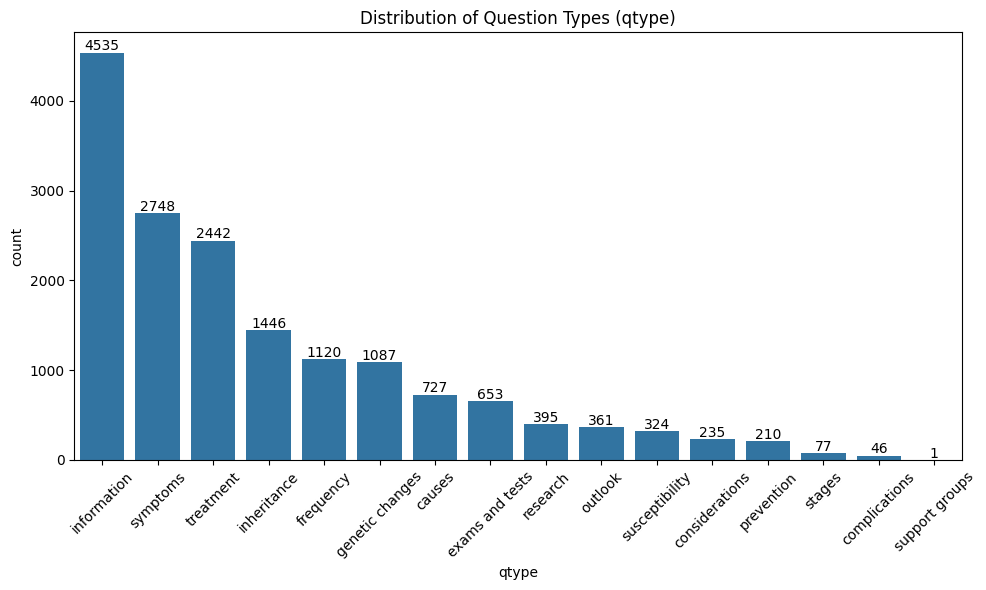

In [6]:
# Plot class distribution
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df, x='qtype', order=df['qtype'].value_counts().index)
plt.title("Distribution of Question Types (qtype)")
plt.xticks(rotation=45)

# Add count labels above each bar
for p in ax.patches:
    height = p.get_height()
    ax.text(
        x=p.get_x() + p.get_width() / 2, 
        y=height + 25,  # slightly above the bar
        s=f'{height:.0f}', 
        ha='center'
    )

plt.tight_layout()
plt.show()

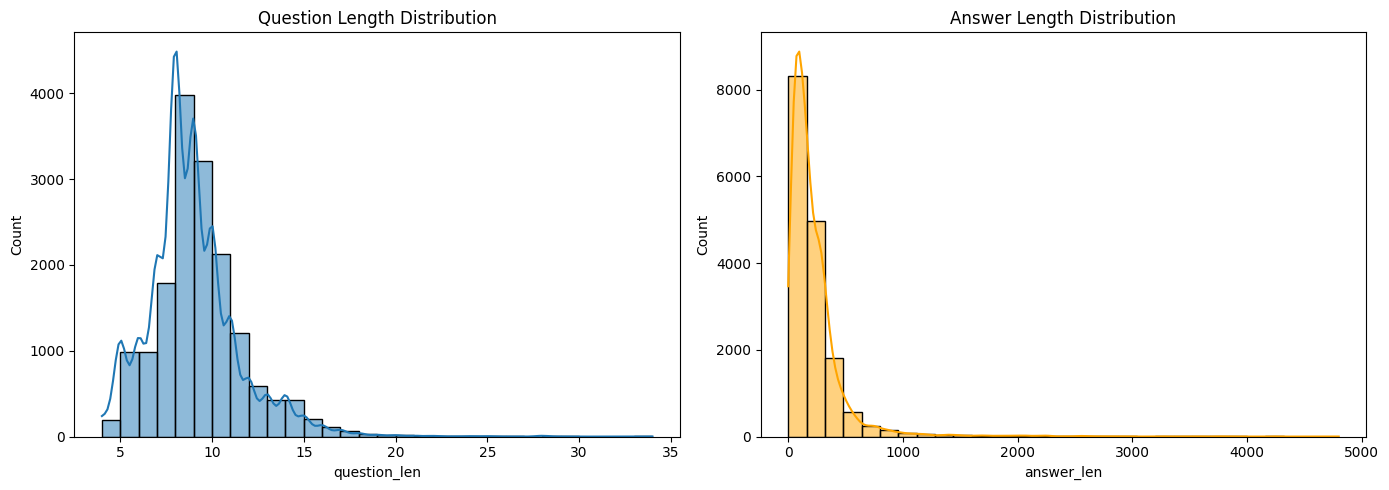

In [ ]:
# Sentence length distributions
df['question_len'] = df['Question'].astype(str).apply(lambda x: len(word_tokenize(x)))
df['answer_len'] = df['Answer'].astype(str).apply(lambda x: len(word_tokenize(x)))

# Plot histograms of sentence lengths
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['question_len'], bins=30, kde=True)
plt.title("Question Length Distribution")

plt.subplot(1, 2, 2)
sns.histplot(df['answer_len'], bins=30, kde=True, color='orange')
plt.title("Answer Length Distribution")
plt.tight_layout()
plt.show()

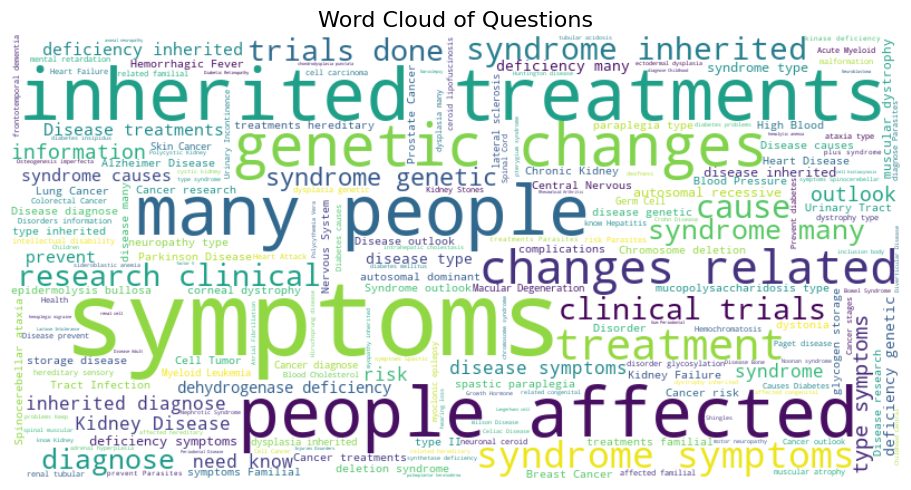

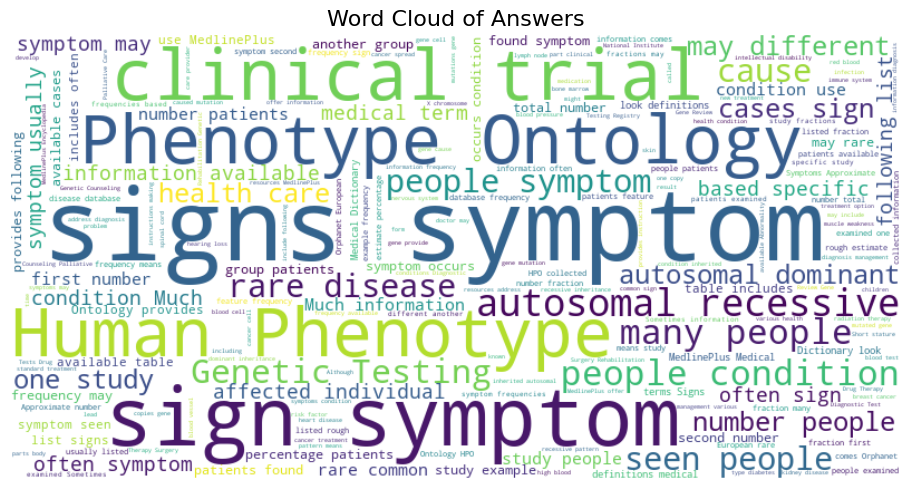

In [12]:
# Word clouds for questions and answers
stop_words = set(stopwords.words('english'))

def generate_wordcloud(text_data, title):
    all_words = ' '.join(text_data.astype(str).tolist())
    word_tokens = word_tokenize(all_words)
    filtered_words = [word for word in word_tokens if word.lower() not in stop_words and word.isalpha()]
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(filtered_words))
    
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(title, fontsize=16)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

generate_wordcloud(df['Question'], "Word Cloud of Questions")
generate_wordcloud(df['Answer'], "Word Cloud of Answers")

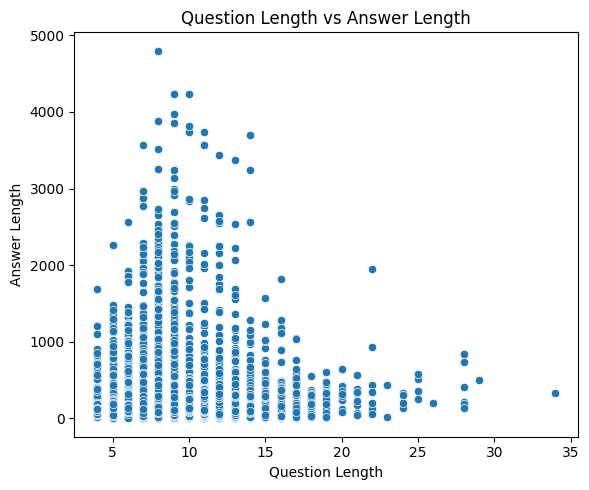

In [11]:
# Correlation between question and answer length
plt.figure(figsize=(6, 5))
sns.scatterplot(data=df, x='question_len', y='answer_len')
plt.title("Question Length vs Answer Length")
plt.xlabel("Question Length")
plt.ylabel("Answer Length")
plt.tight_layout()
plt.show()

In [27]:
# Grouped statistics by qtype
print("\nAverage Lengths by qtype:")
print(df.groupby('qtype')[['question_len', 'answer_len']].mean())

# Top frequent question types and example question
print("\nSample Questions by qtype:")
for label in df['qtype'].value_counts().head(5).index:
    sample_q = df[df['qtype'] == label].iloc[0]['Question']
    print(f"QType: {label} --> Sample Question: {sample_q}")


Average Lengths by qtype:
                 question_len   answer_len
qtype                                     
causes               5.944979   229.269601
complications        8.782609   231.543478
considerations       9.319149   236.548936
exams and tests      7.205207   357.009188
frequency            9.958929    33.742857
genetic changes     10.973321   232.423183
information          8.798236   211.490187
inheritance          5.944675   107.258645
outlook              8.540166    81.315789
prevention           7.861905   349.033333
research            14.584810   168.870886
stages               9.584416  1011.285714
support groups      13.000000   115.000000
susceptibility      10.638889   277.055556
symptoms             9.574964   337.986172
treatment            8.981163   243.788288

Sample Questions by qtype:
QType: information --> Sample Question: What is (are) Parasites - Cysticercosis ?
QType: symptoms --> Sample Question: What are the symptoms of Lymphocytic Choriomeningiti